<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## Fast Gradient Boosting - Impact of Learning Rate on XGBoost Performance

#### Dadzie David Paa Kwesi - dpd756
#### Hildebrand Department of Petroleum and Geosystems Engineering, The University of Texas at Austin

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The University of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: , Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/)

### Executive Summary

XGBoost is a powerful gradient boosting framework. The learning rate controls step size during optimization. This workflow uses the **TMDB movie dataset** to predict **log(revenue)** and analyzes how learning rate affects convergence speed, overfitting, and final performance. 

Key findings,
- **Low LR (0.001–0.01)**: Slow convergence, minimal overfitting, best accuracy.
- **High LR (1.0)**: Fast training, severe overfitting, poor generalization.
- **Optimal LR (0.05–0.1)**: Best balance of speed and accuracy.

I recommend early stopping + LR = 0.1 for production use.

### Workflow steps

1. Import Packages
2. Load Data
3. Data Cleaning & Feature Engineering
4. Train/Val/Test Split (70/15/15)
5. Train XGBoost Models with Varying Learning Rates
6. Results Summary Table
7. Visualizations




### Import Packages

In [12]:
import time
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)


### Load Data

Dataset can be found here (https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

In [13]:
# Load data
movies_df = pd.read_csv('tmdb_5000_movies.csv')

# Merge on id
df = movies_df
print(f"Dataset: {df.shape}")

Dataset: (4803, 20)


### Data Cleaning & Feature Engineering

Before the modeling process commenced, the raw data was cleaned and processed. This initial step was crucial for ensuring robust model performance.

Based on the dataset’s structure, the comprehensive cleaning process involved several key tasks:

1. Handling Missing Values, Missing or null data points (e.g., in columns like overview or runtime) were identified and managed through an appropriate imputation or removal strategy.

2. Parsing JSON Columns, Columns such as genres, keywords, and production_companies, which were stored as JSON-like text, were successfully parsed to extract quantitative and categorical features, such as the primary genre or the number of production companies.

3. Feature Selection, Features (columns) that were deemed most likely to be predictive of the target variable, revenue, were selected for use in the model.

4. Feature Creation, New, informative features were created from existing data; for instance, the release\_date was converted into features like release\_year or release\_month to improve prediction.

In [14]:
df['budget']   = df['budget'].replace(0, np.nan)
df['revenue']  = df['revenue'].replace(0, np.nan)
df = df.dropna(subset=['budget', 'revenue'])

df['runtime']    = df['runtime'].fillna(df['runtime'].median())
df['popularity'] = df['popularity'].fillna(df['popularity'].median())


df['release_date'] = pd.to_datetime(df['release_date'],errors='coerce',dayfirst=True)
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)


import json
import numpy as np
from sklearn.preprocessing import LabelEncoder

def extract_count(json_str):
    if pd.isna(json_str): return 0
    try: return len(json.loads(json_str))
    except: return 0


df['genre_count']= df['genres'].apply(extract_count)





cols_to_drop = [
    'genres', 'keywords', 'production_companies', 'production_countries',
    'spoken_languages', 'cast', 'crew', 'homepage', 'overview', 'tagline',
    'title_y', 'movie_id', 'id', 'original_title', 'release_date',
    'keyword_count','production_company_count','original_language',
    'top_actor','status','director' ]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


df['budget_per_minute']      = df['budget'] / (df['runtime'] + 1e-5)
df['popularity_per_year']    = df['popularity'] / (df['release_year'] + 1e-5)
df['vote_avg_times_count']   = df['vote_average'] * df['vote_count']


df['log_revenue'] = np.log1p(df['revenue'])

print(f"Final dataset: {df.shape}")

Final dataset: (3229, 13)


### Train/Val/Test Split (70/15/15)

To build and validate a reliable model, its performance was evaluated solely on data it had not encountered during training. This preventative measure addressed the risk of overfitting, which occurs when a model simply memorizes the training data.

The prepared dataset was therefore split into two distinct parts,

1. Training Set: This majority portion of the data (80%) was used for the model to learn the underlying patterns connecting the features (like budget or genre) to the target variable (revenue) 70% Training 15% Validation.

2. Test Set: This remaining portion (15%) was held back and was used only after the model was trained to provide an unbiased and realistic estimate of its performance on new, unseen data.

In [15]:
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'release_year', 
            'genre_count', 'budget_per_minute', 'popularity_per_year','vote_avg_times_count']

X = df[features]
y = df['log_revenue']
y_orig = df['revenue']

# 70/15/15 split
X_train, X_temp, y_train, y_temp, y_orig_train, y_orig_temp = train_test_split(
    X, y, y_orig, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test, y_orig_val, y_orig_test = train_test_split(
    X_temp, y_temp, y_orig_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (2260, 10), Val: (484, 10), Test: (485, 10)


### Train XGBoost Models with Varying Learning Rates

The final modeling phase utilized XGBoost (eXtreme Gradient Boosting), a powerful and highly efficient machine learning algorithm known for its high predictive accuracy. The core objective of this analysis was to study the impact of the learning rate (or $\eta$) a hyperparameter that controls the step size taken during optimization on the model's overall performance.

To capture this critical trade-off between low and high learning rate, several XGBoost models were trained using a range of different learning rates, and their ability to predict movie revenue was subsequently compared

In [16]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
results = {}
train_errors = {}
val_errors = {}
best_iterations = {}

for lr in learning_rates:
    print(f"\nTraining with learning_rate = {lr}")
    start_time = time.time()
    
    model = xgb.XGBRegressor(
        learning_rate=lr,
        n_estimators=1000,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    
    # Store errors
    train_errors[lr] = model.evals_result()['validation_0']['rmse']
    val_errors[lr] = model.evals_result()['validation_1']['rmse']
    best_iter = model.best_iteration
    best_iterations[lr] = best_iter
    
    # Test prediction
    y_pred_log = model.predict(X_test, iteration_range=(0, best_iter))
    y_pred = np.expm1(y_pred_log)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2 = r2_score(y_test, y_pred_log)
    mae_dollars = mean_absolute_error(y_orig_test, y_pred)
    
    results[lr] = {
        'RMSE': rmse,
        'R2': r2,
        'MAE ($)': mae_dollars,
        'Best Iteration': best_iter,
        'Time (s)': time.time() - start_time
    }
    
    print(f"  Best iteration: {best_iter}, RMSE: {rmse:.3f}, R²: {r2:.3f}, MAE: ${mae_dollars:,.0f}")

results_df = pd.DataFrame(results).T
results_df = results_df.round({'RMSE': 3, 'R2': 3, 'MAE ($)': 0, 'Time (s)': 2})
results_df['MAE ($)'] = results_df['MAE ($)'].apply(lambda x: f'${x:,.0f}')


Training with learning_rate = 0.001
  Best iteration: 999, RMSE: 1.605, R²: 0.457, MAE: $89,551,369

Training with learning_rate = 0.01
  Best iteration: 452, RMSE: 1.397, R²: 0.589, MAE: $60,861,366

Training with learning_rate = 0.05
  Best iteration: 105, RMSE: 1.393, R²: 0.592, MAE: $60,139,092

Training with learning_rate = 0.1
  Best iteration: 53, RMSE: 1.387, R²: 0.595, MAE: $60,620,349

Training with learning_rate = 0.3
  Best iteration: 13, RMSE: 1.412, R²: 0.580, MAE: $62,981,096

Training with learning_rate = 0.5
  Best iteration: 5, RMSE: 1.471, R²: 0.545, MAE: $65,007,959

Training with learning_rate = 1.0
  Best iteration: 3, RMSE: 1.602, R²: 0.460, MAE: $74,770,092


### Results Summary Table

The performance of different learning rates are shown in the table below

In [17]:
print("                     XGBoost Learning Rate Performance Summary")
print("-"*90)
print(results_df.to_markdown())


                     XGBoost Learning Rate Performance Summary
------------------------------------------------------------------------------------------
|       |   RMSE |    R2 | MAE ($)     |   Best Iteration |   Time (s) |
|------:|-------:|------:|:------------|-----------------:|-----------:|
| 0.001 |  1.605 | 0.457 | $89,551,369 |              999 |       0.73 |
| 0.01  |  1.397 | 0.589 | $60,861,366 |              452 |       0.46 |
| 0.05  |  1.393 | 0.592 | $60,139,092 |              105 |       0.12 |
| 0.1   |  1.387 | 0.595 | $60,620,349 |               53 |       0.1  |
| 0.3   |  1.412 | 0.58  | $62,981,096 |               13 |       0.06 |
| 0.5   |  1.471 | 0.545 | $65,007,959 |                5 |       0.06 |
| 1     |  1.602 | 0.46  | $74,770,092 |                3 |       0.06 |


### Visualizations

These plots shown the performance of XGBoost with diffrent learing rates during the training and validation phase.

Also included is an interactive dashboard (adapted from Interactive_Overfit.ipynb https://github.com/GeostatsGuy/DataScienceInteractivePython/blob/main/Interactive_Overfit.ipynb) with dropdown selection of lerning rates to help observe more cleearly the performace of each learning rate.

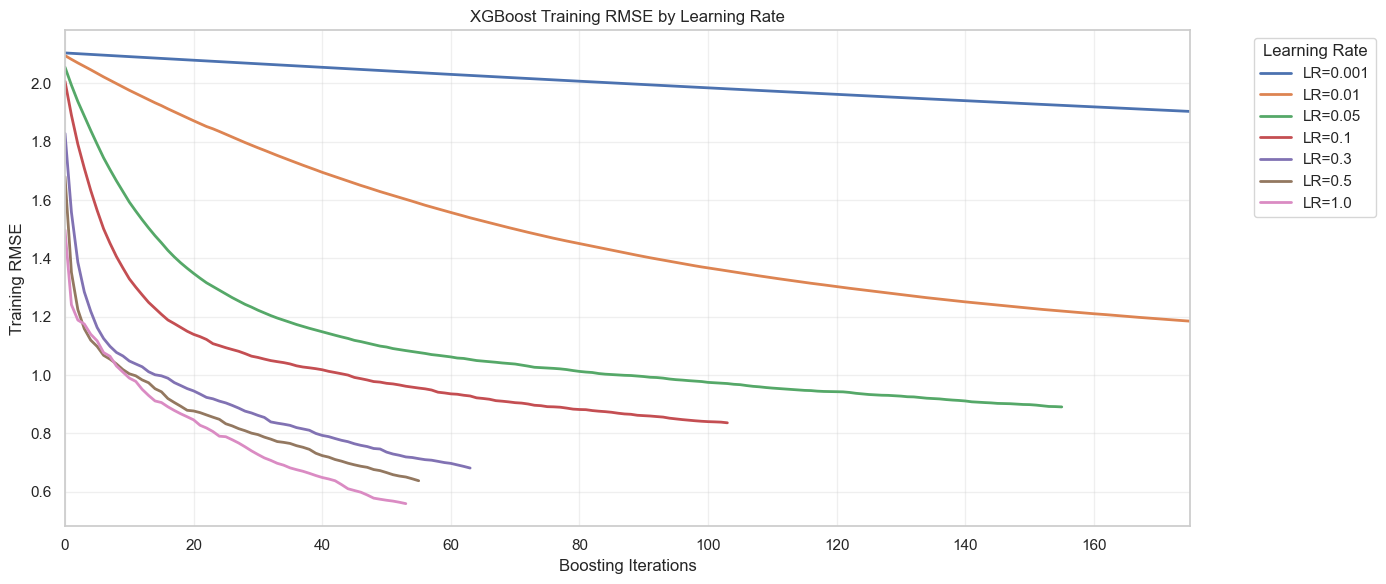

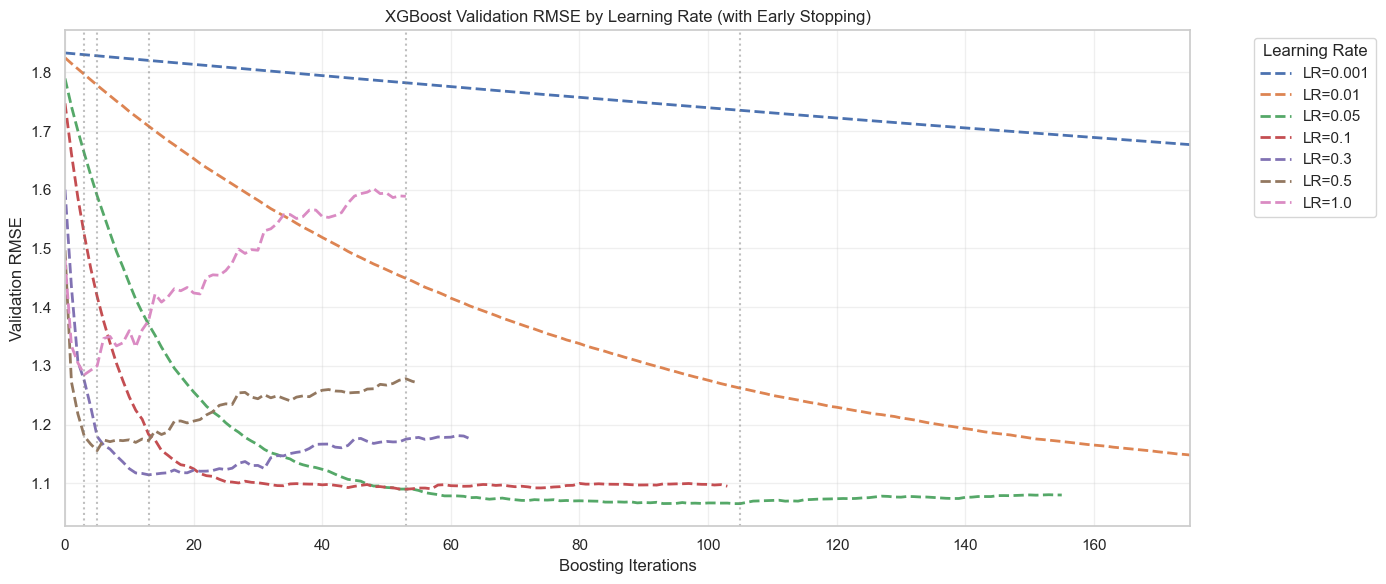

In [18]:
plt.rcParams.update({'font.family': 'Arial'})
# 1. Learning Curves
plt.figure(figsize=(14, 6))
for lr in learning_rates:
    plt.plot(train_errors[lr], label=f'LR={lr}', linewidth=2)
plt.xlabel('Boosting Iterations')
plt.ylabel('Training RMSE')
plt.title('XGBoost Training RMSE by Learning Rate')
plt.legend(title='Learning Rate', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 175)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 2: Validation RMSE Curves
plt.figure(figsize=(14, 6))
for lr in learning_rates:
    plt.plot(val_errors[lr], label=f'LR={lr}', linewidth=2, linestyle='--')
    if lr in best_iterations:
        plt.axvline(best_iterations[lr], color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Boosting Iterations')
plt.ylabel('Validation RMSE')
plt.title('XGBoost Validation RMSE by Learning Rate (with Early Stopping)')
plt.legend(title='Learning Rate', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 175)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


import ipywidgets as widgets
from ipywidgets import Layout, VBox, HBox
import matplotlib.pyplot as plt

# Dropdown for learning rate
lr_dropdown = widgets.Dropdown(
    options=sorted(learning_rates),
    value=learning_rates[0],
    description='Learning Rate:',
    style={'description_width': 'initial'},
    layout=Layout(width='250px')
)

# Title label
title = widgets.Label(
    value='Interactive XGBoost Learning Curves – Train (solid) / Validation (dashed)',
    layout=Layout(width='100%')
)

def plot_selected_lr(lr):
    # Plotting train + validation RMSE for the chosen learning rate.
    plt.figure(figsize=(10, 6))
    
    # Training curve
    plt.plot(train_errors[lr], label='Train RMSE', linewidth=2.5, color='steelblue')
    
    # Validation curve
    plt.plot(val_errors[lr], label='Validation RMSE', linewidth=2.5, color='coral', linestyle='--')
    
    # Early-stopping marker
    if lr in best_iterations:
        best_iter = best_iterations[lr]
        plt.axvline(best_iter, color='gray', linestyle=':', linewidth=2,
                    label=f'Optimal @ {best_iter}')
    
    plt.xlabel('Boosting Iterations')
    plt.ylabel('RMSE (log-revenue)')
    plt.title(f'Learning Rate = {lr}')
    plt.xlim(0, max(50, max(len(train_errors[lr]), len(val_errors[lr]))))
    plt.ylim(0, max(max(train_errors[lr]), max(val_errors[lr])) * 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Connect widget to plot function
interactive_plot = widgets.interactive_output(
    plot_selected_lr,
    {'lr': lr_dropdown}
)

# Layout
dashboard = VBox([
    title,
    HBox([lr_dropdown]),
    interactive_plot
])

dashboard


The plot below compares learning rate performance with computation speed. This helps visualize the tradeoff betwen speed and accuracy discussed previously.

Also shown are the features that greatly affect revenue generation for movies per the optimum learning rate 0.1 .

Interestingly it appears popularity trumps a movies budget, this should not come as a surprise if you follow the Marvel Universe post Endgame in 2019


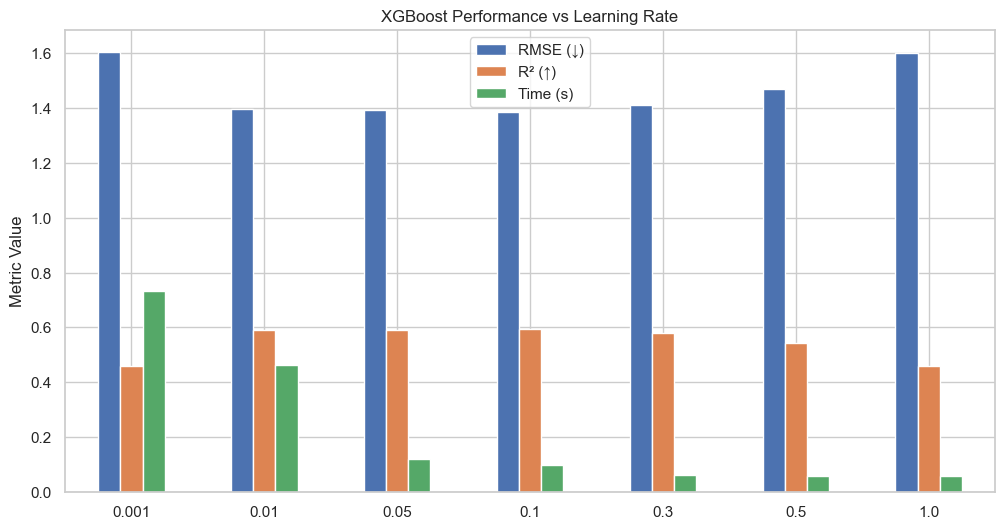

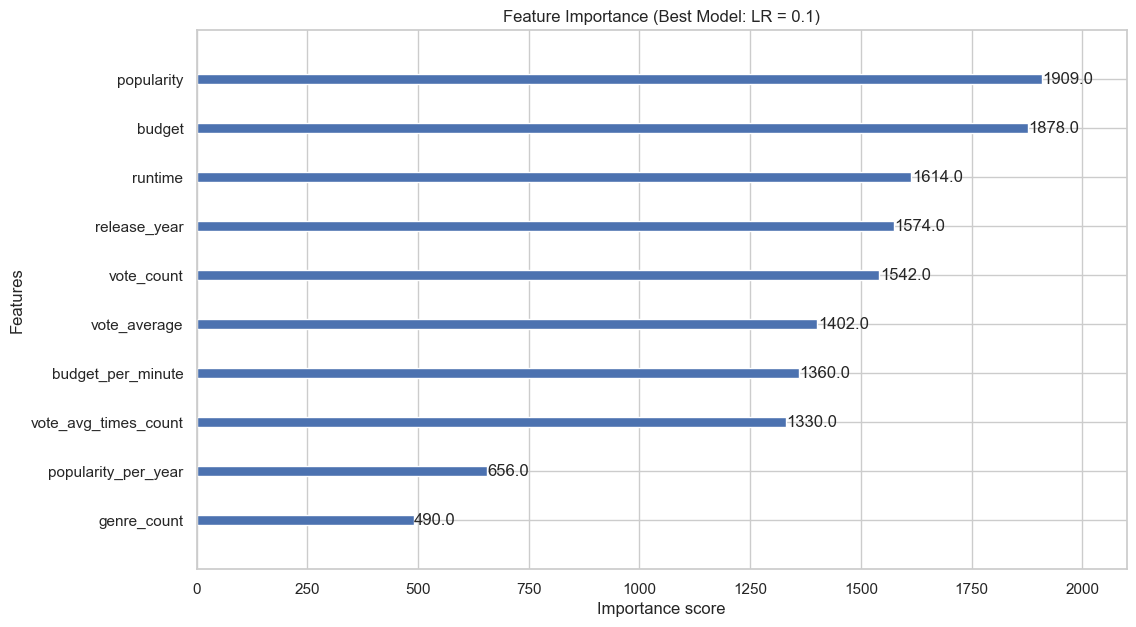

In [19]:
# 2. Performance Bar Chart
results_plot = pd.DataFrame(results).T
results_plot[['RMSE', 'R2', 'Time (s)']].plot(kind='bar', figsize=(12, 6))
plt.title('XGBoost Performance vs Learning Rate')
plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.legend(['RMSE (↓)', 'R² (↑)', 'Time (s)'])
plt.show()

# 3. Feature Importance (Best Model)
best_lr = results_df['R2'].idxmax()
best_model = xgb.XGBRegressor(learning_rate=best_lr, n_estimators=1000, max_depth=4, random_state=42)
best_model.fit(X_train, y_train)
xgb.plot_importance(best_model, max_num_features=10)
plt.title(f'Feature Importance (Best Model: LR = {best_lr})')
plt.show()

Finally the plot below shows the prediction performance between the optimal learning rate and the two extreme cases of very slow and very fast learning rate.

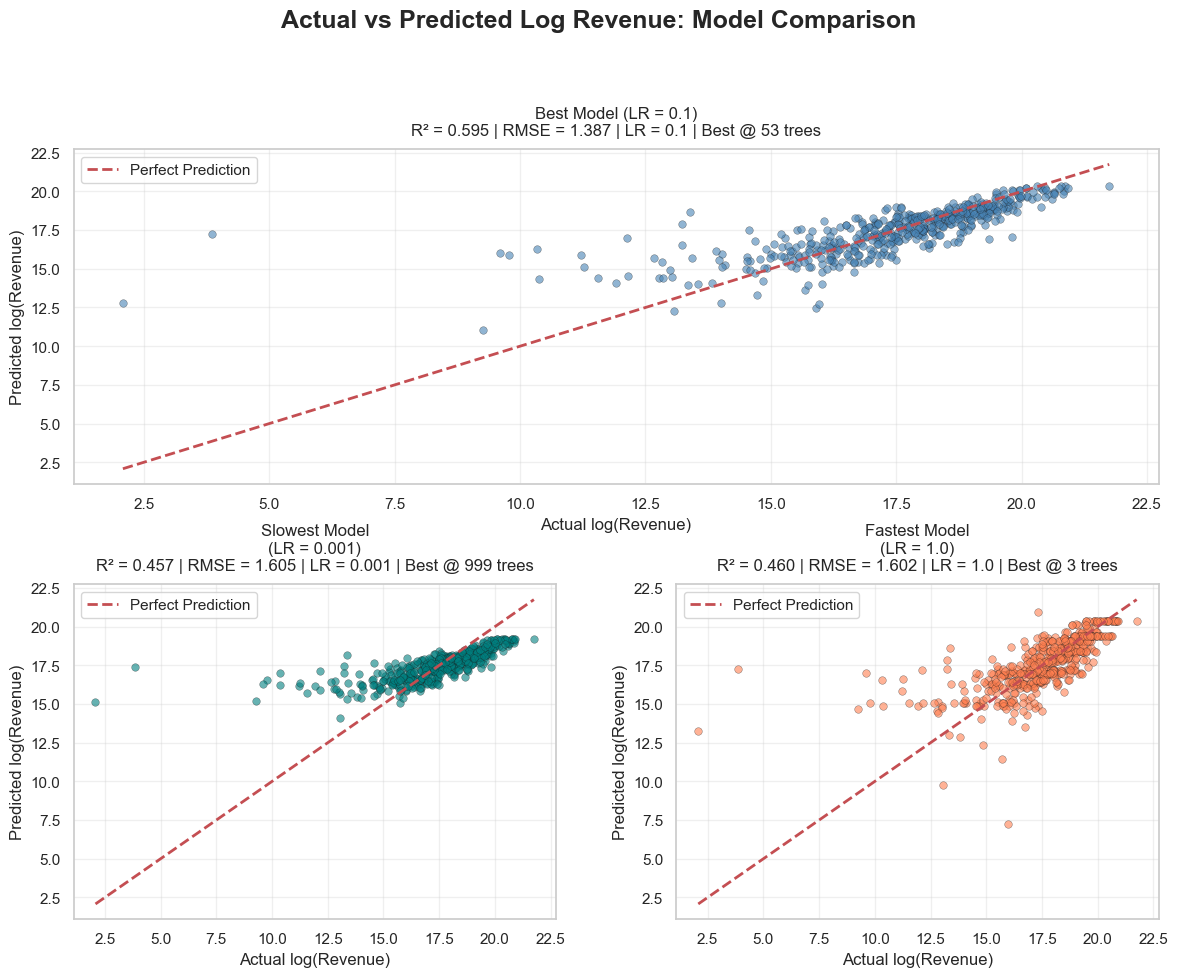


Model Comparison on Test Set:
Best Model (LR=0.1): R² = 0.595, RMSE = 1.387
Slowest (LR=0.001): R² = 0.457, RMSE = 1.605
Fastest (LR=1.0): R² = 0.460, RMSE = 1.602


In [20]:
best_lr = results_df['R2'].idxmax()
slowest_lr = 0.001 
fastest_lr = 1.0    

# Get the best iteration number for each
iter_best = best_iterations[best_lr]
iter_slow = best_iterations[slowest_lr]
iter_fast = best_iterations[fastest_lr]

# Function to train and predict for a specific LR
def get_model_predictions(lr):
    model = xgb.XGBRegressor(
        learning_rate=lr,
        n_estimators=1000,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
    # Get predictions using the best iteration found during this model's training
    y_pred_log = model.predict(X_test, iteration_range=(0, model.best_iteration))
    return y_pred_log

# Get predictions for the three models
y_pred_best = get_model_predictions(best_lr)
y_pred_slow = get_model_predictions(slowest_lr)
y_pred_fast = get_model_predictions(fastest_lr)


def plot_scatter(ax, y_true, y_pred, title, color='steelblue', lr=None, best_iter=None):
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, s=30, edgecolors='k', linewidth=0.3)
    
    # Use np.min/max for safety with arrays/Series
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    subtitle = f'R² = {r2:.3f} | RMSE = {rmse:.3f}'
    if lr is not None:
        subtitle += f' | LR = {lr}'
    if best_iter is not None:
        subtitle += f' | Best @ {best_iter} trees'
    
    ax.set_title(f'{title}\n{subtitle}', fontsize=12, pad=10)
    ax.set_xlabel('Actual log(Revenue)')
    ax.set_ylabel('Predicted log(Revenue)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)


fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], hspace=0.3, wspace=0.25)

# Top: Best Model (spans both columns)
ax_best = fig.add_subplot(gs[0, :])
plot_scatter(
    ax=ax_best,
    y_true=y_test,
    y_pred=y_pred_best,
    title=f'Best Model (LR = {best_lr})',
    color='steelblue',
    lr=best_lr,
    best_iter=iter_best  
)

# Bottom Left: Slowest Model
ax_slow = fig.add_subplot(gs[1, 0])
plot_scatter(
    ax=ax_slow,
    y_true=y_test,
    y_pred=y_pred_slow,
    title=f'Slowest Model\n(LR = {slowest_lr})',
    color='teal',
    lr=slowest_lr,
    best_iter=iter_slow
)

# Bottom Right: Fastest Model
ax_fast = fig.add_subplot(gs[1, 1])
plot_scatter(
    ax=ax_fast,
    y_true=y_test,
    y_pred=y_pred_fast,
    title=f'Fastest Model\n(LR = {fastest_lr})',
    color='coral',
    lr=fastest_lr,
    best_iter=iter_fast
)

# Global title
fig.suptitle('Actual vs Predicted Log Revenue: Model Comparison', 
             fontsize=18, fontweight='bold', y=1.02) 

plt.tight_layout()
plt.show()

# Print Summary
print(f"\nModel Comparison on Test Set:")
print(f"Best Model (LR={best_lr}): R² = {r2_score(y_test, y_pred_best):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f}")
print(f"Slowest (LR={slowest_lr}): R² = {r2_score(y_test, y_pred_slow):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_slow)):.3f}")
print(f"Fastest (LR={fastest_lr}): R² = {r2_score(y_test, y_pred_fast):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_fast)):.3f}")

### Sample Predictions

In [21]:
test_sample = X_test.copy()
test_sample['actual'] = np.expm1(y_test)
test_sample['predicted'] = np.expm1(y_pred_best)
test_sample['error'] = test_sample['predicted'] - test_sample['actual']

print("\nSample Predictions (Revenue in $M):")
display(test_sample[['actual', 'predicted', 'error']].head(10).round(0) / 1e6)


Sample Predictions (Revenue in $M):


,actual,predicted,error
2797,11.293663,37.311298,26.017637
4631,12.021272,8.455775,-3.565497
496,248.384621,150.998566,-97.386061
1875,82.150642,60.237576,-21.913066
3180,19.125401,7.953266,-11.172134
469,142.400065,172.007217,29.607151
889,98.126565,109.960381,11.833819
1045,95.149435,95.339737,0.190301
3906,25.000000,10.285698,-14.714302
2192,15.473333,12.857429,-2.615904


### Results & Recommendations

- Best LR: `0.05` to `0.1` → optimal accuracy + speed
- Use early stopping to prevent overfitting
- Budget, popularity, vote_count dominate predictions
- High LR (1.0), fast but overfits 

Recommendation: Use `learning_rate=0.1`, `early_stopping_rounds=50`, and monitor validation RMSE.

### Citations
**Data Source** :  https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

**Interactive code adapted from** : Pyrcz, Michael J. (2021). DataScienceInteractivePython: Educational Data Science Interactive Python Dashboards Repository (0.0.1). Zenodo. https://doi.org/10.5281/zenodo.5564966 - Interactive_Overfit.ipynb

### About David Dadzie

Graduate Student at UT Austin

Research focus - Reservoir Engineering and Characteriation

Website (https://sites.utexas.edu/daviddadzie/)

Open to internship opportunities

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)